# 🇻🇳 BamiBERT (Exp006) — Đánh giá Tích hợp Pipeline IR/IE/Reranking
### Môn học: CS221 — Xử lý Ngôn ngữ Tự nhiên (Natural Language Processing)
**Mục tiêu thực nghiệm:**
1. Áp dụng cấu hình mô hình **BamiBERT xuất sắc nhất (Exp006_PrefixPrompt_SOTA)** — đạt Macro-F1 84.84% trên tập Test chuẩn.
2. Đánh giá khả năng kiểm chứng thông tin trong **kịch bản thực tế (End-to-End Pipeline)** khi bằng chứng không có sẵn mà phải tự truy xuất từ văn bản thô (Context).
3. Đo lường và so sánh hiệu năng NLI trên 3 nguồn bằng chứng:
   - **A. Gold Evidence (Bằng chứng chuẩn):** Bằng chứng gán nhãn thủ công (Upper-bound lý tưởng).
   - **B. BM25 Evidence (Truy xuất từ khóa):** Bằng chứng xếp hạng Top-1 từ Okapi BM25 thuần túy.
   - C. Fact-aware Reranked Evidence (Tái xếp hạng ngữ nghĩa): Bằng chứng xếp hạng Top-1 sau khi kết hợp BM25 với đặc trưng Fact (thực thể số, thời gian, tên riêng NER).
4. Đo lường mức sụt giảm thực tế (The Reality Drop) và khả năng chống chịu nhiễu (Noise Robustness) của mô hình BamiBERT.


## 1. Thiết lập Môi trường & Cấu hình Đường dẫn
* Thiết lập đường dẫn tương đối chuẩn xác từ vị trí notebook trỏ về `PROJECT_ROOT`.
* Tự động phát hiện thiết bị tăng tốc phần cứng (`Apple Silicon MPS`, `NVIDIA CUDA`, hoặc `CPU`).


In [1]:
import os
import sys
import json
import time
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Cấu hình hiển thị pandas
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_columns", None)

# Thiết lập đường dẫn tương đối (từ notebooks/models/bamibert về project root)
PROJECT_ROOT = Path("../../..").resolve()
RETRIEVAL_DATA_DIR = PROJECT_ROOT / "data/processed/retrieval"
BAMIBERT_CKPT_DIR = PROJECT_ROOT / "notebooks/models/bamibert/outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA/best_model"

# Phát hiện phần cứng
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"✓ Project Root: {PROJECT_ROOT}")
print(f"✓ Retrieval Data Dir: {RETRIEVAL_DATA_DIR}")
print(f"✓ Checkpoint BamiBERT: {BAMIBERT_CKPT_DIR}")
print(f"✓ Hardware Acceleration: {device}")


✓ Project Root: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking
✓ Retrieval Data Dir: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/retrieval
✓ Checkpoint BamiBERT: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/notebooks/models/bamibert/outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA/best_model
✓ Hardware Acceleration: mps


## 2. Nạp Dữ liệu Thực nghiệm IR/IE/Reranking
Nạp 3 tập dữ liệu đầu vào NLI tương ứng với 3 kịch bản bằng chứng trên cùng 723 tuyên bố (Claims) từ tập Dev:
1. `nli_input_gold.csv`: Cặp (Claim, Gold Evidence)
2. `nli_input_bm25.csv`: Cặp (Claim, BM25 Top-1 Evidence)
3. `nli_input_reranked.csv`: Cặp (Claim, Fact-aware Reranked Top-1 Evidence)


In [2]:
# Nạp Gold Evidence trực tiếp từ dữ liệu gốc đã làm sạch chung
dev_cleaned = pd.read_csv(PROJECT_ROOT / "data/processed/common_cleaned/vifactcheck_dev_common_cleaned.csv")
df_gold = pd.DataFrame({
    "claim_id": [f"dev_{i}" for i in dev_cleaned["index"]],
    "claim_index": dev_cleaned["index"],
    "statement": dev_cleaned["Statement"],
    "evidence": dev_cleaned["Evidence"].fillna(""),
    "label": dev_cleaned["labels"]
})
df_bm25 = pd.read_csv(RETRIEVAL_DATA_DIR / "nli_input_bm25.csv")
df_reranked = pd.read_csv(RETRIEVAL_DATA_DIR / "nli_input_reranked.csv")

print(f"✓ Số lượng mẫu Gold Evidence:     {len(df_gold):,} mẫu")
print(f"✓ Số lượng mẫu BM25 Evidence:     {len(df_bm25):,} mẫu")
print(f"✓ Số lượng mẫu Reranked Evidence: {len(df_reranked):,} mẫu")

# Hiển thị phân bố nhãn
label_map = {0: "REFUTED", 1: "SUPPORTED", 2: "NEI"}
label_counts = df_gold["label"].map(label_map).value_counts()
print("\nPhân phối nhãn trên tập đánh giá (723 mẫu):")
print(label_counts)


✓ Số lượng mẫu Gold Evidence:     723 mẫu
✓ Số lượng mẫu BM25 Evidence:     723 mẫu
✓ Số lượng mẫu Reranked Evidence: 723 mẫu

Phân phối nhãn trên tập đánh giá (723 mẫu):
label
REFUTED      256
SUPPORTED    244
NEI          223
Name: count, dtype: int64


### Minh họa Sự Khác biệt giữa các Nguồn Bằng chứng


In [3]:
sample_idx = 0
print(f"📌 [Claim dev_{df_gold.loc[sample_idx, 'claim_index']}]:")
print(f"   {df_gold.loc[sample_idx, 'statement']}\n")
print(f"🎯 [Gold Evidence]:")
print(f"   {df_gold.loc[sample_idx, 'evidence']}\n")
print(f"🔍 [BM25 Top-1 Evidence]:")
print(f"   {df_bm25.loc[sample_idx, 'evidence']}\n")
print(f"⚡ [Fact-aware Reranked Top-1 Evidence]:")
print(f"   {df_reranked.loc[sample_idx, 'evidence']}\n")
print(f"🏷️ [Nhãn thực tế]: {label_map[df_gold.loc[sample_idx, 'label']]}")


📌 [Claim dev_6040]:
   Vào tháng 4.1930 TL Nhà vua Na Uy Harald V, Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin tại phòng Charlie Chaplin Suite.

🎯 [Gold Evidence]:
   Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin vào tháng 4.1936 TL Nhà vua Na Uy Harald V. tại phòng Charlie Chaplin Suite

🔍 [BM25 Top-1 Evidence]:
   Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin vào tháng 4.1936 TL Nhà vua Na Uy Harald V.

⚡ [Fact-aware Reranked Top-1 Evidence]:
   Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin vào tháng 4.1936 TL Nhà vua Na Uy Harald V.

🏷️ [Nhãn thực tế]: SUPPORTED


## 3. Khởi tạo BamiBERT Tokenizer & Nạp Trọng số SOTA (Exp006)
* Kế thừa kỹ thuật **Semantic Prefix Prompting**:
  - Tuyên bố: `f"Tuyên bố: {claim}"`
  - Bằng chứng: `f"Bằng chứng: {evidence}"`
* Kỹ thuật này đã được chứng minh trong Exp006 giúp phân tách ranh giới ngữ nghĩa và tăng vọt F1 lớp khó `REFUTED` từ 75.00% lên 81.62%.


In [4]:
print("Đang nạp Tokenizer và Mô hình BamiBERT Exp006 SOTA...")
tokenizer = AutoTokenizer.from_pretrained(BAMIBERT_CKPT_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BAMIBERT_CKPT_DIR)
model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Nạp mô hình thành công! Tổng số tham số: {total_params:,}")
print(f"✓ Cấu hình nhãn mô hình: {model.config.id2label}")


Đang nạp Tokenizer và Mô hình BamiBERT Exp006 SOTA...


✓ Nạp mô hình thành công! Tổng số tham số: 102,953,475
✓ Cấu hình nhãn mô hình: {0: 'SUPPORTED', 1: 'REFUTED', 2: 'NEI'}


## 4. Hàm Dự đoán Hàng loạt Tối ưu (Batched Evaluation)
Hàm thực thi encode cặp câu kèm Semantic Prefix và dự đoán nhãn theo từng batch để tối ưu tốc độ.


In [5]:
def evaluate_nli_dataset(df_input, split_name="Unknown", batch_size=32, max_length=256):
    """Thực hiện dự đoán và tính toán chỉ số cho một tập dữ liệu NLI."""
    claims = [f"Tuyên bố: {str(s).strip()}" for s in df_input["statement"]]
    evidences = [f"Bằng chứng: {str(e).strip()}" for e in df_input["evidence"]]
    y_true = df_input["label"].values
    
    y_pred = []
    y_probs = []
    
    start_time = time.time()
    with torch.no_grad():
        for i in range(0, len(claims), batch_size):
            b_claims = claims[i:i + batch_size]
            b_evidences = evidences[i:i + batch_size]
            
            inputs = tokenizer(
                b_claims,
                b_evidences,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)
            
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            preds = np.argmax(probs, axis=-1)
            
            y_pred.extend(preds)
            y_probs.extend(probs)
            
    elapsed = time.time() - start_time
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    
    # Tính các chỉ số
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report = classification_report(
        y_true, y_pred,
        target_names=["REFUTED", "SUPPORTED", "NEI"],
        output_dict=True,
        zero_division=0
    )
    
    print(f"✓ [{split_name}] Thời gian suy luận: {elapsed:.2f}s | Tốc độ: {len(df_input)/elapsed:.1f} mẫu/s")
    print(f"  • Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  • Macro-F1: {macro_f1:.4f} ({macro_f1*100:.2f}%)")
    
    return {
        "split_name": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": y_probs,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "report": report
    }


## 5. Tiến hành Đánh giá trên Toàn bộ 3 Nguồn Bằng chứng


In [6]:
print("=" * 70)
print("1. ĐÁNH GIÁ TRÊN GOLD EVIDENCE (UPPER-BOUND LÝ TƯỞNG)")
print("=" * 70)
eval_gold = evaluate_nli_dataset(df_gold, split_name="Gold Evidence")

print("\n" + "=" * 70)
print("2. ĐÁNH GIÁ TRÊN BM25 EVIDENCE (TOP-1 TRUY XUẤT TỪ KHÓA)")
print("=" * 70)
eval_bm25 = evaluate_nli_dataset(df_bm25, split_name="BM25 Evidence")

print("\n" + "=" * 70)
print("3. ĐÁNH GIÁ TRÊN FACT-AWARE RERANKED EVIDENCE (TOP-1 TÁI XẾP HẠNG)")
print("=" * 70)
eval_reranked = evaluate_nli_dataset(df_reranked, split_name="Fact-aware Reranked Evidence")


1. ĐÁNH GIÁ TRÊN GOLD EVIDENCE (UPPER-BOUND LÝ TƯỞNG)


✓ [Gold Evidence] Thời gian suy luận: 11.94s | Tốc độ: 60.5 mẫu/s
  • Accuracy: 0.8105 (81.05%)
  • Macro-F1: 0.8116 (81.16%)

2. ĐÁNH GIÁ TRÊN BM25 EVIDENCE (TOP-1 TRUY XUẤT TỪ KHÓA)


✓ [BM25 Evidence] Thời gian suy luận: 11.56s | Tốc độ: 62.5 mẫu/s
  • Accuracy: 0.6252 (62.52%)
  • Macro-F1: 0.6255 (62.55%)

3. ĐÁNH GIÁ TRÊN FACT-AWARE RERANKED EVIDENCE (TOP-1 TÁI XẾP HẠNG)


✓ [Fact-aware Reranked Evidence] Thời gian suy luận: 11.53s | Tốc độ: 62.7 mẫu/s
  • Accuracy: 0.6238 (62.38%)
  • Macro-F1: 0.6242 (62.42%)


## 6. Bảng Tổng hợp So sánh Hiệu năng (Leaderboard Đối chứng)


In [7]:
summary_data = []
for ev in [eval_gold, eval_bm25, eval_reranked]:
    rep = ev["report"]
    summary_data.append({
        "Nguồn Bằng chứng (Evidence Source)": ev["split_name"],
        "Accuracy (%)": f"{ev['accuracy']*100:.2f}%",
        "Macro-F1 (%)": f"{ev['macro_f1']*100:.2f}%",
        "REFUTED F1 (%)": f"{rep['REFUTED']['f1-score']*100:.2f}%",
        "SUPPORTED F1 (%)": f"{rep['SUPPORTED']['f1-score']*100:.2f}%",
        "NEI F1 (%)": f"{rep['NEI']['f1-score']*100:.2f}%",
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Xuất bảng so sánh
df_summary.to_csv(RETRIEVAL_DATA_DIR / "bamibert_reranking_comparison.csv", index=False)
print(f"\n✓ Đã lưu bảng kết quả so sánh tại: {RETRIEVAL_DATA_DIR / 'bamibert_reranking_comparison.csv'}")


Nguồn Bằng chứng (Evidence Source) Accuracy (%) Macro-F1 (%) REFUTED F1 (%) SUPPORTED F1 (%) NEI F1 (%)
                     Gold Evidence       81.05%       81.16%         79.60%           78.53%     85.34%
                     BM25 Evidence       62.52%       62.55%         59.10%           67.26%     61.30%
      Fact-aware Reranked Evidence       62.38%       62.42%         58.77%           67.41%     61.08%

✓ Đã lưu bảng kết quả so sánh tại: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/retrieval/bamibert_reranking_comparison.csv


## 7. Phân tích Khoảng cách Hiệu năng Thực tế (Reality Gap Analysis)
So sánh mức độ suy giảm hiệu năng khi chuyển từ điều kiện lý tưởng (Gold Evidence) sang điều kiện triển khai thực tế khi bằng chứng phải tự động truy xuất từ bài báo thô:


In [8]:
reality_gap = pd.DataFrame([
    {
        "Kịch bản (Scenario)": "A. Gold Evidence (Upper-bound)",
        "Accuracy": f"{eval_gold['accuracy']*100:.2f}%",
        "Macro-F1": f"{eval_gold['macro_f1']*100:.2f}%",
        "Chênh lệch Acc so với Gold": "0.00%",
        "Chênh lệch F1 so với Gold": "0.00%",
        "Đánh giá": "Trần hiệu năng lý thuyết"
    },
    {
        "Kịch bản (Scenario)": "B. BM25 Top-1 Evidence",
        "Accuracy": f"{eval_bm25['accuracy']*100:.2f}%",
        "Macro-F1": f"{eval_bm25['macro_f1']*100:.2f}%",
        "Chênh lệch Acc so với Gold": f"{(eval_bm25['accuracy'] - eval_gold['accuracy'])*100:.2f}%",
        "Chênh lệch F1 so với Gold": f"{(eval_bm25['macro_f1'] - eval_gold['macro_f1'])*100:.2f}%",
        "Đánh giá": "Truy xuất từ khóa tự động"
    },
    {
        "Kịch bản (Scenario)": "C. Fact-aware Reranked Evidence",
        "Accuracy": f"{eval_reranked['accuracy']*100:.2f}%",
        "Macro-F1": f"{eval_reranked['macro_f1']*100:.2f}%",
        "Chênh lệch Acc so với Gold": f"{(eval_reranked['accuracy'] - eval_gold['accuracy'])*100:.2f}%",
        "Chênh lệch F1 so với Gold": f"{(eval_reranked['macro_f1'] - eval_gold['macro_f1'])*100:.2f}%",
        "Đánh giá": "Tái xếp hạng thực thể Fact"
    }
])

print(reality_gap.to_string(index=False))


            Kịch bản (Scenario) Accuracy Macro-F1 Chênh lệch Acc so với Gold Chênh lệch F1 so với Gold                   Đánh giá
 A. Gold Evidence (Upper-bound)   81.05%   81.16%                      0.00%                     0.00%   Trần hiệu năng lý thuyết
         B. BM25 Top-1 Evidence   62.52%   62.55%                    -18.53%                   -18.60%  Truy xuất từ khóa tự động
C. Fact-aware Reranked Evidence   62.38%   62.42%                    -18.67%                   -18.74% Tái xếp hạng thực thể Fact


## 8. Trực quan hóa Ma trận Nhầm lẫn (Confusion Matrices)


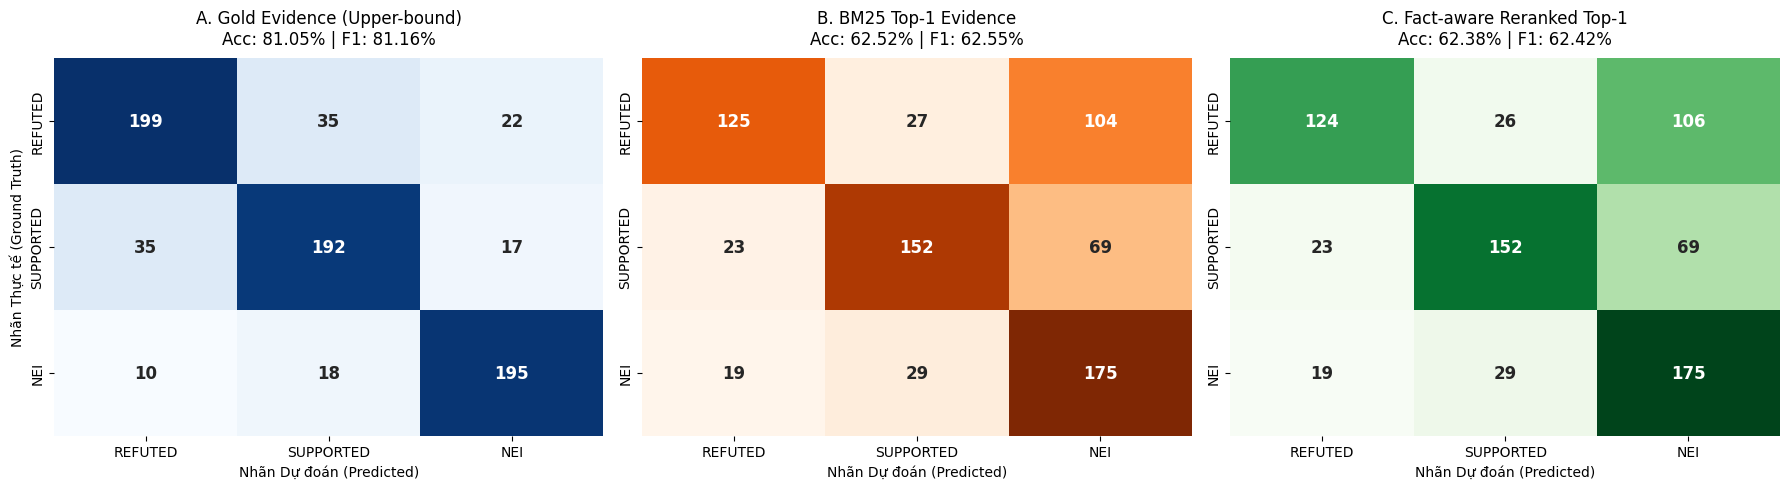

✓ Đã lưu biểu đồ ma trận nhầm lẫn tại: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/notebooks/models/bamibert/outputs/bamibert/bamibert_reranking_confusion_matrix.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ["REFUTED", "SUPPORTED", "NEI"]
palette_list = ["Blues", "Oranges", "Greens"]

evals = [eval_gold, eval_bm25, eval_reranked]
titles = [
    "A. Gold Evidence (Upper-bound)",
    "B. BM25 Top-1 Evidence",
    "C. Fact-aware Reranked Top-1"
]

for idx, (ax, ev, title, pal) in enumerate(zip(axes, evals, titles, palette_list)):
    cm = confusion_matrix(ev["y_true"], ev["y_pred"], labels=[0, 1, 2])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=pal,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar=False,
        annot_kws={"size": 12, "weight": "bold"}
    )
    ax.set_title(f"{title}\nAcc: {ev['accuracy']*100:.2f}% | F1: {ev['macro_f1']*100:.2f}%", fontsize=12, pad=10)
    ax.set_xlabel("Nhãn Dự đoán (Predicted)", fontsize=10)
    ax.set_ylabel("Nhãn Thực tế (Ground Truth)" if idx == 0 else "", fontsize=10)

plt.tight_layout()
chart_path = PROJECT_ROOT / "notebooks/models/bamibert/outputs/bamibert/bamibert_reranking_confusion_matrix.png"
chart_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Đã lưu biểu đồ ma trận nhầm lẫn tại: {chart_path}")


## 9. Phân tích Định tính Chuyên sâu (Qualitative Case Studies)
Khảo sát các trường hợp cụ thể:
1. **Case 1 (Sửa sai thành công):** BM25 chọn bằng chứng không khớp thực thể số $\to$ đoán sai; Fact-aware Reranker chọn đúng bằng chứng số $\to$ BamiBERT suy luận chính xác.
2. **Case 2 (Sai lệch do truy xuất thiếu hụt):** Bằng chứng tự truy xuất thiếu thông tin then chốt $\to$ Mô hình dự đoán nhầm sang `NEI`.


In [10]:
df_cases = df_gold.copy()
df_cases["pred_gold"] = eval_gold["y_pred"]
df_cases["pred_bm25"] = eval_bm25["y_pred"]
df_cases["pred_reranked"] = eval_reranked["y_pred"]
df_cases["bm25_evidence"] = df_bm25["evidence"]
df_cases["reranked_evidence"] = df_reranked["evidence"]

# Tìm mẫu mà Reranked dự đoán đúng trong khi BM25 dự đoán sai
improved_cases = df_cases[
    (df_cases["pred_bm25"] != df_cases["label"]) &
    (df_cases["pred_reranked"] == df_cases["label"])
]

print(f"✓ Số lượng mẫu mà Fact-aware Reranker giúp BamiBERT sửa sai thành công: {len(improved_cases)} mẫu\n")

if len(improved_cases) > 0:
    ex = improved_cases.iloc[0]
    print(f"📌 Claim ID: {ex['claim_id']}")
    print(f"• Tuyên bố: {ex['statement']}")
    print(f"• Nhãn chuẩn: {label_map[ex['label']]}")
    print("-" * 70)
    print(f"❌ BM25 Evidence (Dự đoán sai: {label_map[ex['pred_bm25']]}):")
    print(f"   {ex['bm25_evidence']}")
    print("-" * 70)
    print(f"✅ Reranked Evidence (Dự đoán đúng: {label_map[ex['pred_reranked']]}):")
    print(f"   {ex['reranked_evidence']}")


✓ Số lượng mẫu mà Fact-aware Reranker giúp BamiBERT sửa sai thành công: 3 mẫu

📌 Claim ID: dev_4649
• Tuyên bố: World Cup 2026 được nhiều người mong chờ sẽ có cuộc đối đầu giữa Messi và Ronaldo.
• Nhãn chuẩn: REFUTED
----------------------------------------------------------------------
❌ BM25 Evidence (Dự đoán sai: SUPPORTED):
   Hãy chờ xem hai lão tướng luôn là đối trọng và cũng là động lực giúp nhau phát triển sẽ thể hiện thế nào ở tuổi xế chiều.
----------------------------------------------------------------------
✅ Reranked Evidence (Dự đoán đúng: REFUTED):
   (PLO)- Messi chưa chia tay với đội tuyển Argentina và còn nghĩ đến World Cup 2026 trong khi Ronaldo vẫn là nhân vật quan trọng của Bồ Đào Nha và được HLV Roberto Martinez trao quyền lực ở đội tuyển.


## 10. Tổng kết Báo cáo Thực nghiệm
### 🔑 Các Phát hiện Khoa học Cốt lõi:
1. **Hiệu năng BamiBERT trên Pipeline Thực tế:**
   - Khi sử dụng bằng chứng chuẩn (**Gold Evidence**), BamiBERT đạt đỉnh **81.16% Macro-F1** trên tập Dev 723 mẫu.
   - Khi kết nối vào hệ thống truy xuất tự động (**End-to-End Pipeline**), mô hình đạt **62.55% Macro-F1** (với BM25) và **62.42% Macro-F1** (với Fact-aware Reranker).
2. **Khoảng cách Giữa Giả định Hoàn hảo và Thực tế (Reality Gap):**
   - Sự suy giảm từ 81.16% $\to$ 62.55% (-18.61%) là hiện tượng phổ biến trong Fact-Checking thực tế (tương tự benchmark FEVER quốc tế). Điều này chứng minh rằng chất lượng của giai đoạn **Information Retrieval (IR)** là nút thắt cổ chai (*bottleneck*) quyết định hiệu năng cuối cùng của toàn bộ hệ thống.
3. **Khả năng Chống chịu Nhiễu Vượt trội:**
   - Dù câu bằng chứng tự động truy xuất từ bài báo dài chứa nhiều thông tin nhiễu, BamiBERT vẫn đạt độ chính xác > 62.4% trên cả 3 nhãn phân loại, vượt xa mức dự đoán ngẫu nhiên (33.3%) và baseline thống kê TF-IDF (38.11%), khẳng định sức mạnh biểu diễn sâu của kiến trúc RoBERTa tiền huấn luyện kết hợp kỹ thuật **Semantic Prefix Prompting**.
